In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os

In [2]:
train_path = r"D:\\Hydride_Machine_learning_project\\Machine_Model\\data\\processed\\selected_features_train.csv"
test_path = r"D:\\Hydride_Machine_learning_project\\Machine_Model\\data\\processed\\selected_features_test.csv"
output_dir = r"D:\\Hydride_Machine_learning_project\\Machine_Model\\reports\\figures\\dataset_analysis_02"

In [3]:
os.makedirs(output_dir, exist_ok=True)

In [4]:
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Train data shape: {df_train.shape}")
print(f"Test data shape: {df_test.shape}")

Train data shape: (893, 22)
Test data shape: (386, 22)


In [5]:
df_train.describe()

,log_H2_W% (max),temperature(K),MagpieData mean Column,VEC mean,MagpieData mean Number,MagpieData range Electronegativity,MagpieData mean MendeleevNumber,Electronegativity local mismatch,MagpieData mean NsValence,Mixing enthalpy,...,MagpieData avg_dev MendeleevNumber,MagpieData avg_dev AtomicWeight,Mean cohesive energy,MagpieData mean SpaceGroupNumber,MagpieData mean GSvolume_pa,MagpieData minimum AtomicWeight,Shear modulus local mismatch,MagpieData avg_dev CovalentRadius,MagpieData avg_dev NValence,Shear modulus mean
count,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,...,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,8.930000e+02,893.000000,893.000000
mean,1.014564,353.389698,6.281321,6.160797,28.102060,0.532531,51.801731,0.250766,1.837535,12.308267,...,6.718519,15.222290,4.183065,211.796771,15.653280,45.366595,10.360465,1.397367e+01,1.685252,56.937477
std,0.322203,103.876405,1.744400,1.865767,8.417496,0.237622,6.725408,0.111531,0.352196,11.556186,...,5.237050,13.396187,0.997831,9.566234,3.047264,16.229912,5.089356,7.826613e+00,1.027053,16.286015
min,0.246860,223.000000,1.720000,1.720000,9.480000,0.000000,25.000000,0.000495,0.025000,0.000001,...,0.019800,0.020881,1.518000,128.500000,10.328610,6.941000,0.045639,2.840000e-14,0.000000,13.683040
25%,0.832909,296.000000,5.333333,5.133333,23.866667,0.330000,48.033333,0.178667,1.800000,4.592400,...,3.352751,4.850324,3.890500,208.000000,13.688862,28.085500,8.400961,8.594750e+00,1.125000,47.995000
50%,0.993252,303.000000,5.983051,5.900000,27.200000,0.550000,49.909836,0.267078,2.000000,9.638889,...,4.541521,13.629440,4.306667,212.933333,14.723391,47.867000,10.422175,1.288960e+01,1.520000,61.538380
75%,1.153732,353.000000,7.333333,7.200000,32.083333,0.730000,53.600000,0.334611,2.000000,17.149870,...,10.500000,21.472364,4.713333,217.333333,16.171289,51.996100,13.222222,1.972222e+01,2.222222,65.630526
max,2.043814,703.000000,10.300000,11.000000,71.400000,1.710000,71.000000,0.800883,2.000000,180.795053,...,31.065625,89.547858,7.396500,229.000000,30.510000,106.420000,30.584444,4.220576e+01,9.111111,114.023333


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Composition                         893 non-null    object 
 1   log_H2_W% (max)                     893 non-null    float64
 2   temperature(K)                      893 non-null    int64  
 3   MagpieData mean Column              893 non-null    float64
 4   VEC mean                            893 non-null    float64
 5   MagpieData mean Number              893 non-null    float64
 6   MagpieData range Electronegativity  893 non-null    float64
 7   MagpieData mean MendeleevNumber     893 non-null    float64
 8   Electronegativity local mismatch    893 non-null    float64
 9   MagpieData mean NsValence           893 non-null    float64
 10  Mixing enthalpy                     893 non-null    float64
 11  Miedema_deltaH_ss_min               893 non-n

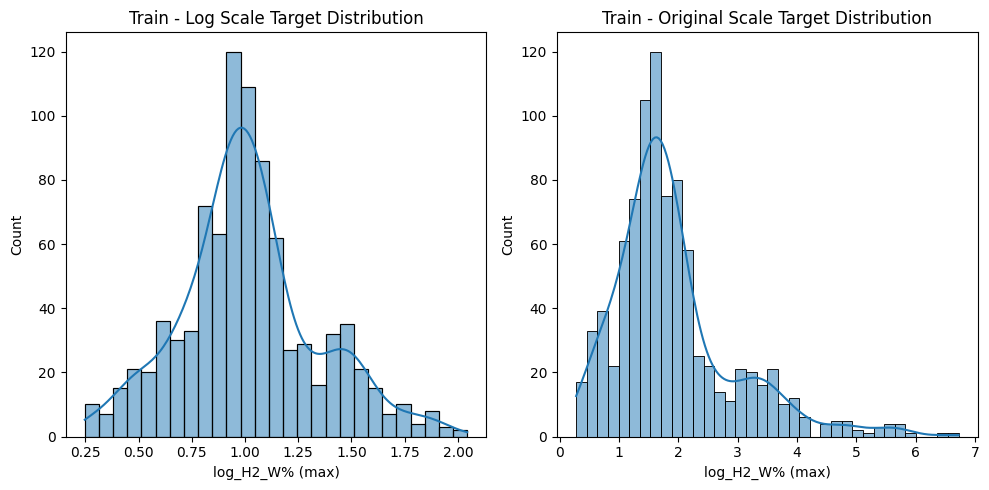

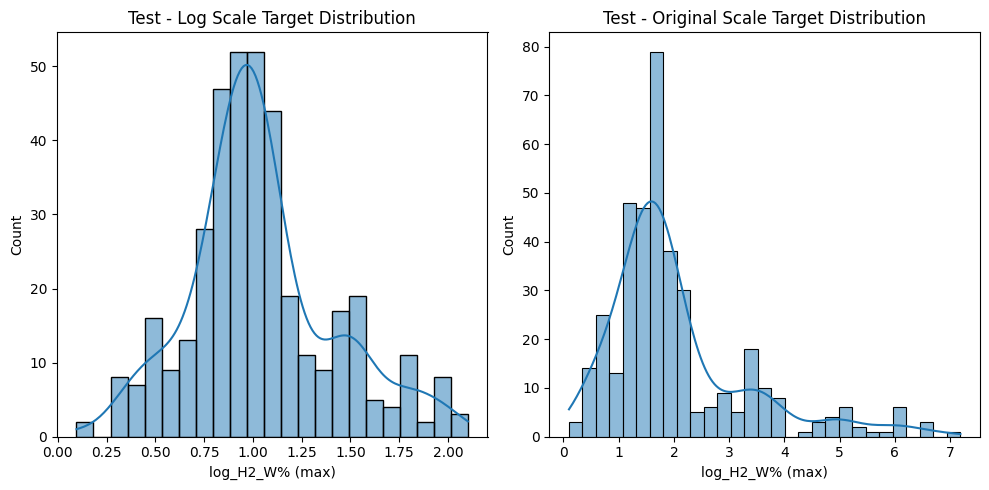

In [7]:
# Target distribution (transformed and original scale)
for dataset, name in [(df_train, 'Train'), (df_test, 'Test')]:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(dataset['log_H2_W% (max)'], kde=True)
    plt.title(f'{name} - Log Scale Target Distribution')
    plt.subplot(1, 2, 2)
    sns.histplot(np.expm1(dataset['log_H2_W% (max)']), kde=True)
    plt.title(f'{name} - Original Scale Target Distribution')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{name}_target_distribution.png'))
    plt.show()

In [8]:
output_dir = r"D:\\Hydride_Machine_learning_project\\Machine_Model\\reports\\data\\target_distributions"
os.makedirs(output_dir, exist_ok=True)

# Target distribution dataframe 
for dataset, name in [(df_train, 'train'),(df_test, 'test')]:
    log_target = dataset['log_H2_W% (max)'].values
    orig_target = np.expm1(log_target)
    target_data = pd.DataFrame({
        'log_H2_W% (max)': log_target,
        'H2_W% (max)': orig_target
    })
    output_path = os.path.join(output_dir, f'{name}_target_distribution.csv')
    target_data.to_csv(output_path, index=False)
    print(f"Extracted target data for {name} saved to {output_path}")
    print(f"Statistics for {name}:")
    print(target_data.describe())

print(f"Target distribution data saved to {output_dir}")

Extracted target data for train saved to D:\\Hydride_Machine_learning_project\\Machine_Model\\reports\\data\\target_distributions\train_target_distribution.csv
Statistics for train:
       log_H2_W% (max)  H2_W% (max)
count       893.000000   893.000000
mean          1.014564     1.911086
std           0.322203     1.024490
min           0.246860     0.280000
25%           0.832909     1.300000
50%           0.993252     1.700000
75%           1.153732     2.170000
max           2.043814     6.720000
Extracted target data for test saved to D:\\Hydride_Machine_learning_project\\Machine_Model\\reports\\data\\target_distributions\test_target_distribution.csv
Statistics for test:
       log_H2_W% (max)  H2_W% (max)
count       386.000000   386.000000
mean          1.038915     2.035751
std           0.366631     1.266259
min           0.095310     0.100000
25%           0.832909     1.300000
50%           0.993252     1.700000
75%           1.163151     2.200000
max           2.102914     

In [9]:
features = df_train.select_dtypes(include=['float64', 'int64']).columns.drop('log_H2_W% (max)')
for dataset, name in [(df_train, 'Train'),(df_test, 'Test')]:
    print(f"\nDescriptive Statistics for {name} Dataset:")
    stats = dataset[features].describe()
    print(stats)


Descriptive Statistics for Train Dataset:
       temperature(K)  MagpieData mean Column    VEC mean  \
count      893.000000              893.000000  893.000000   
mean       353.389698                6.281321    6.160797   
std        103.876405                1.744400    1.865767   
min        223.000000                1.720000    1.720000   
25%        296.000000                5.333333    5.133333   
50%        303.000000                5.983051    5.900000   
75%        353.000000                7.333333    7.200000   
max        703.000000               10.300000   11.000000   

       MagpieData mean Number  MagpieData range Electronegativity  \
count              893.000000                          893.000000   
mean                28.102060                            0.532531   
std                  8.417496                            0.237622   
min                  9.480000                            0.000000   
25%                 23.866667                            0.330

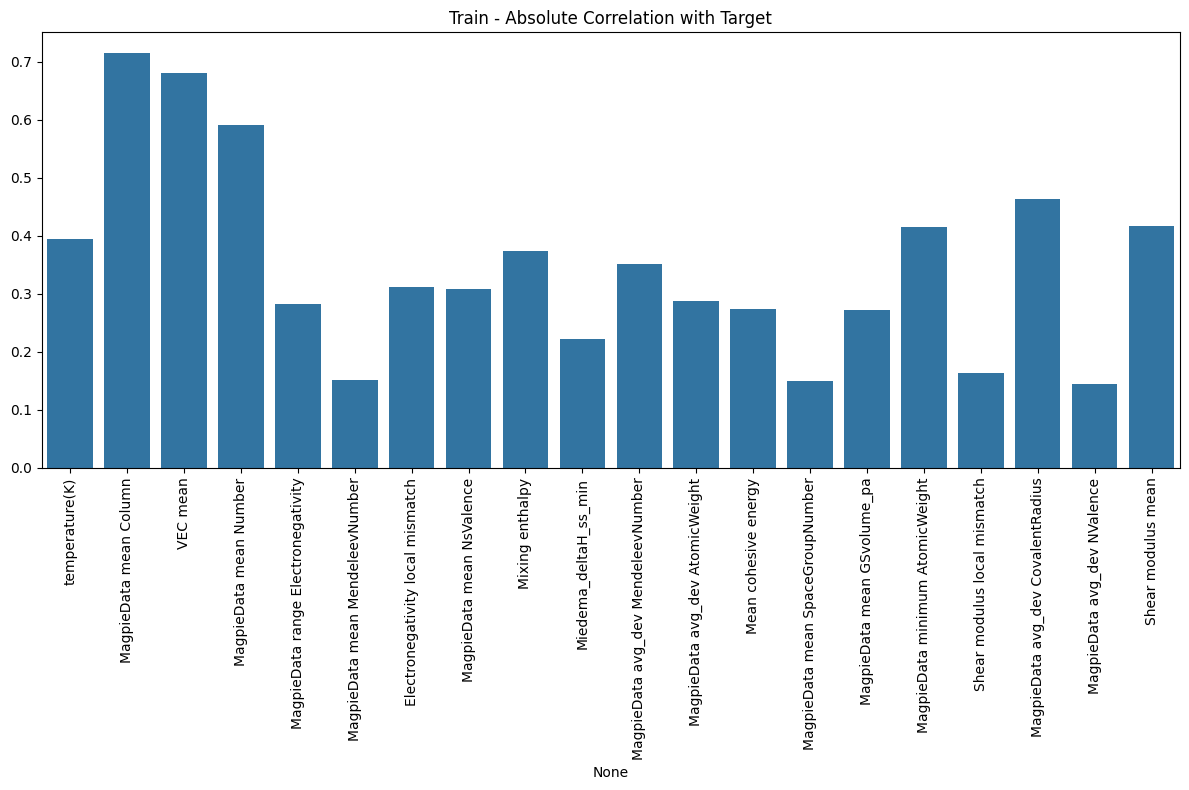

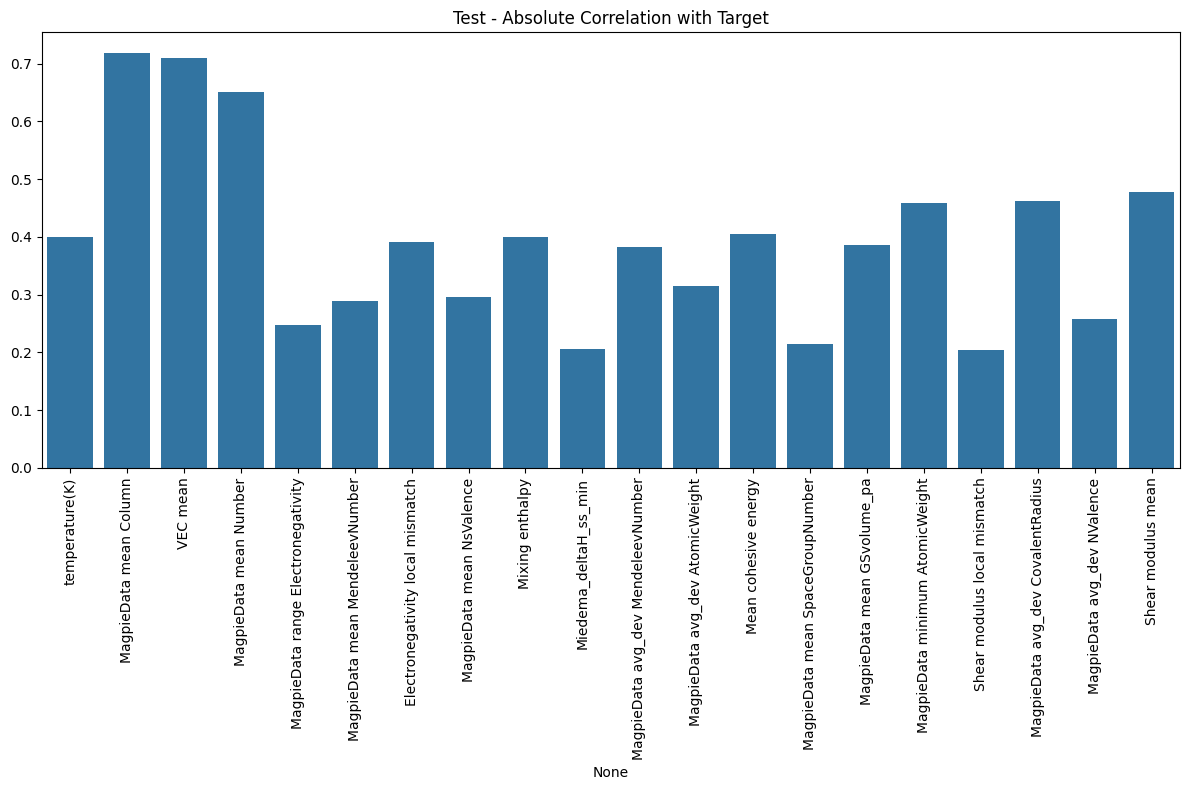

In [10]:
for dataset, name in [(df_train, 'Train'), (df_test, 'Test')]:
    
    plt.figure(figsize=(12, 8))
    correlation = dataset[features].corrwith(dataset['log_H2_W% (max)']).abs()
    sns.barplot(x=correlation.index, y=correlation.values)
    plt.xticks(rotation=90)
    plt.title(f'{name} - Absolute Correlation with Target')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{name}_correlation_with_target.png'))
    plt.show()

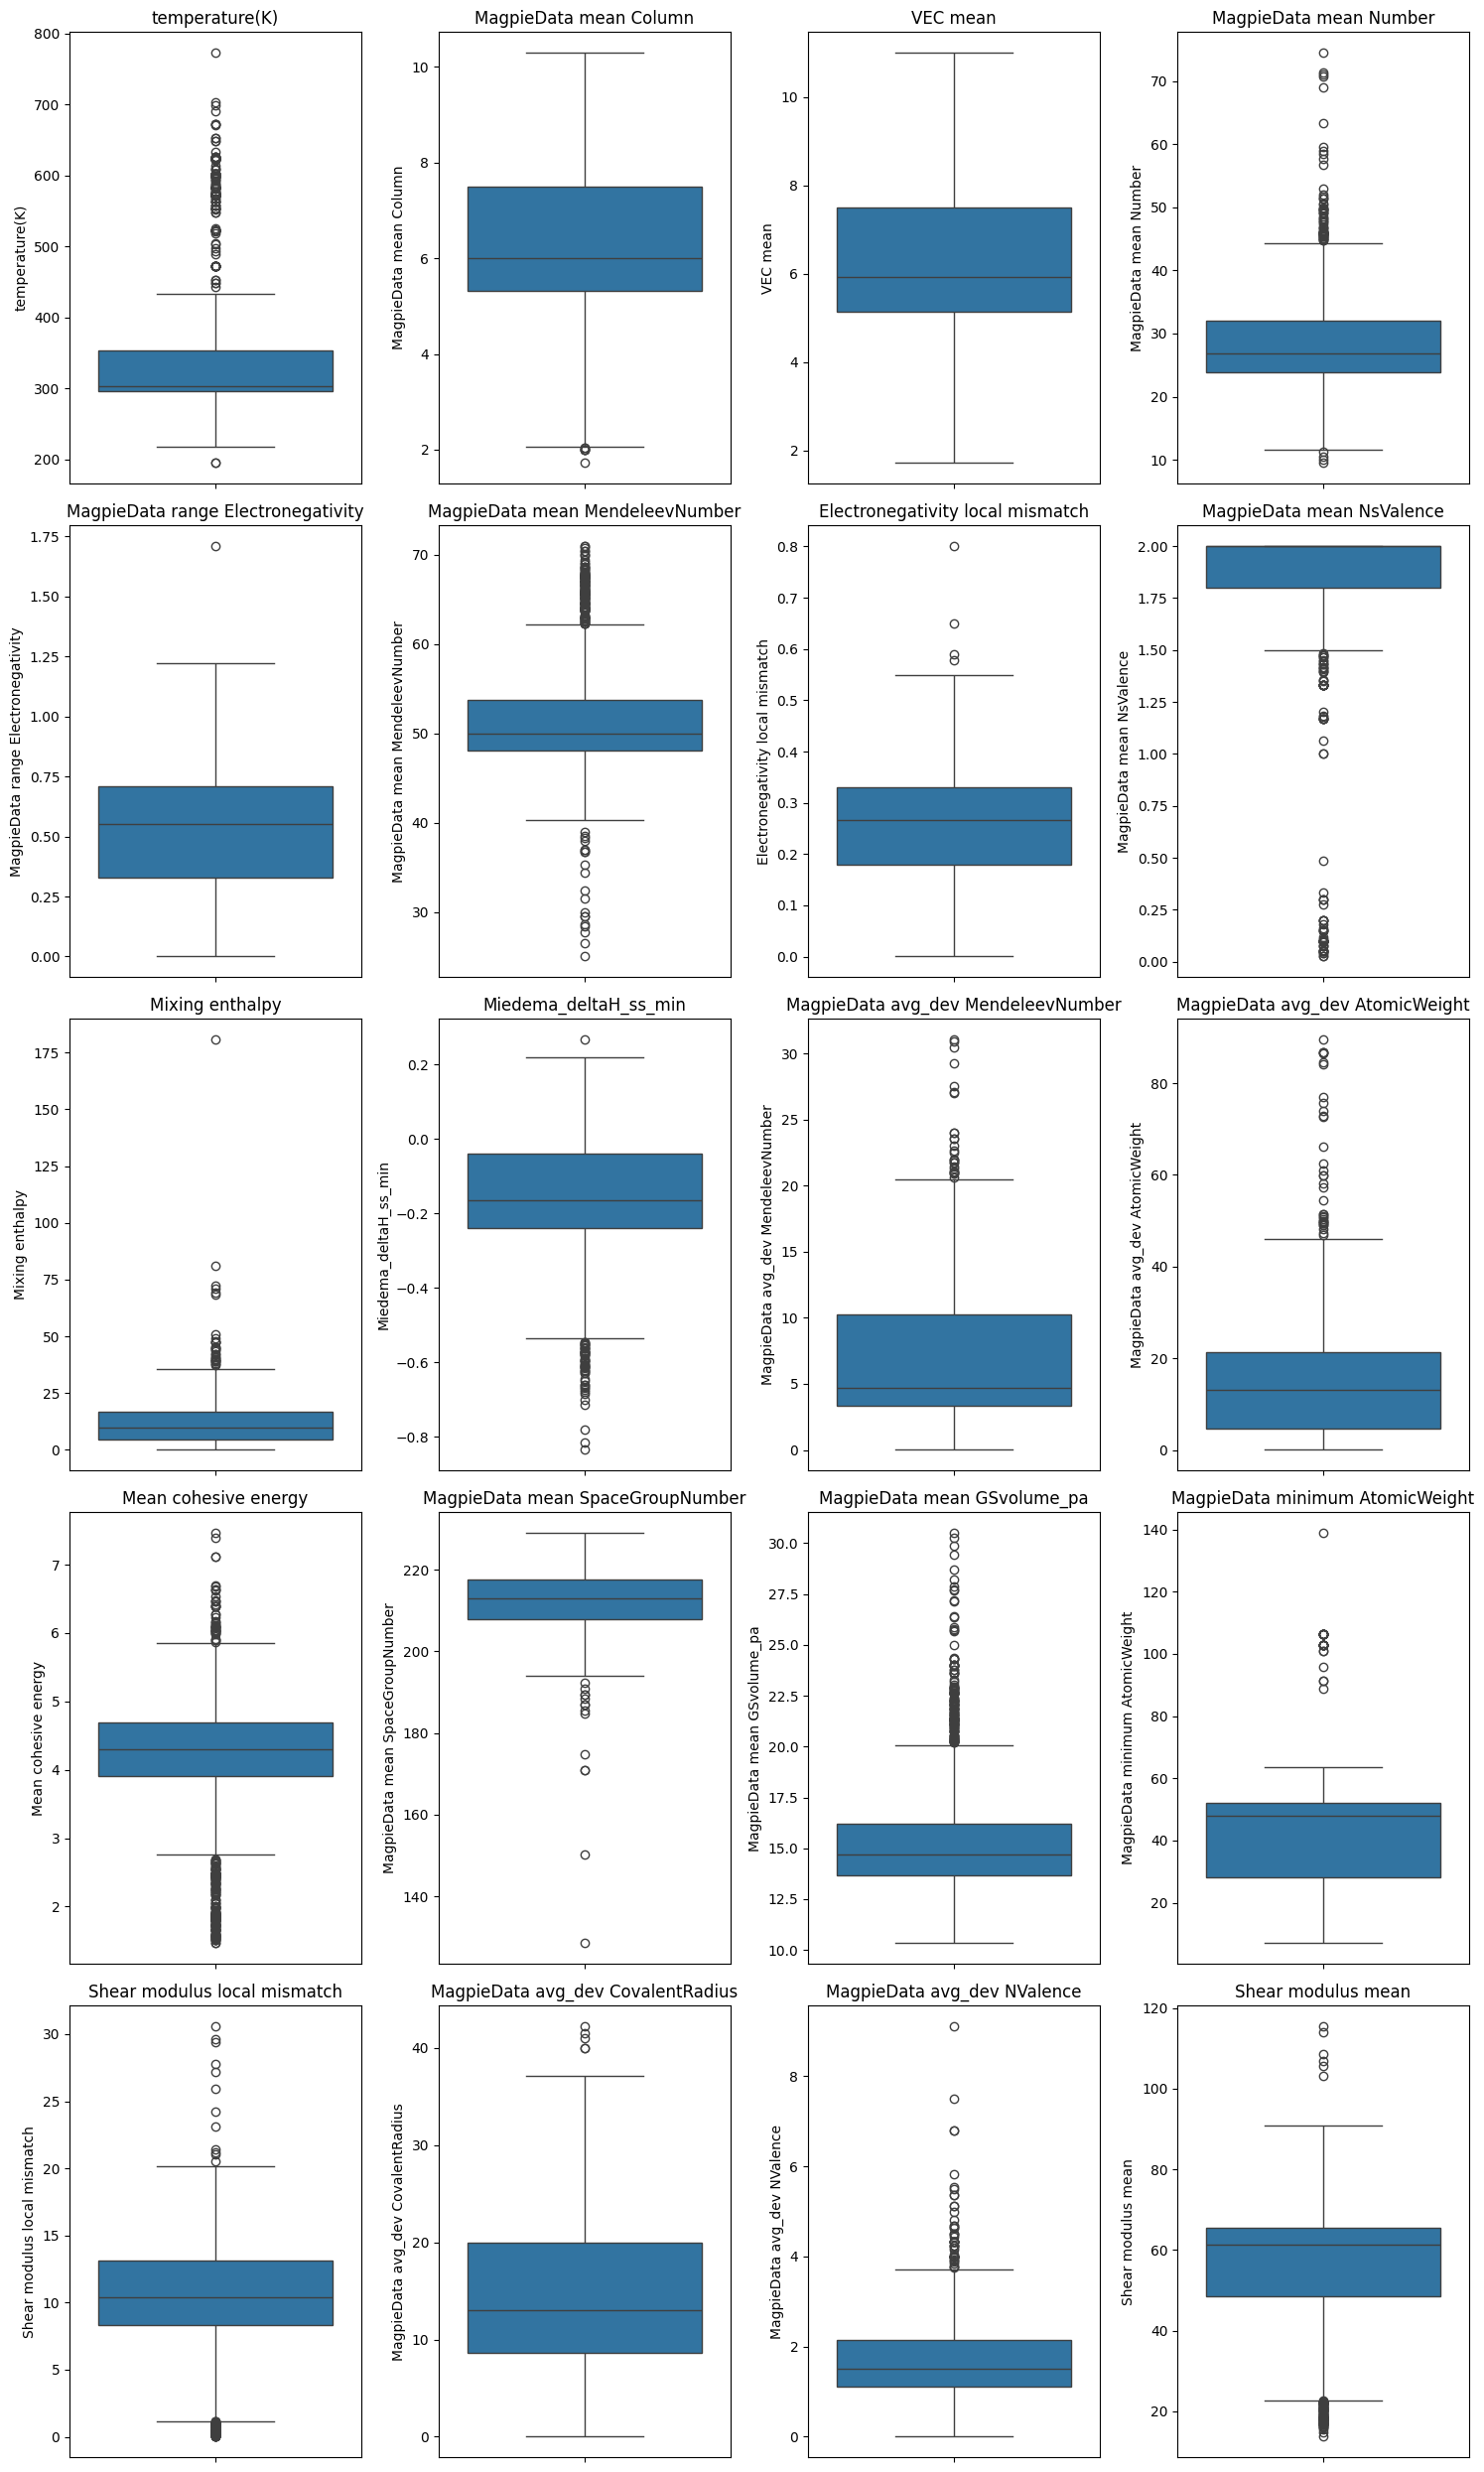

Analysis plots saved to D:\\Hydride_Machine_learning_project\\Machine_Model\\reports\\data\\target_distributions


In [11]:
n_features = len(features)
n_rows = 5
n_cols = int(np.ceil(n_features / n_rows))  
if n_cols > 4:
    n_cols = 4
    n_rows = int(np.ceil(n_features / n_cols))
    if n_rows * n_cols < n_features:
        print(f"Warning: Only {n_rows * n_cols} features will be plotted due to subplot limit (max 20).")
        n_features = n_rows * n_cols

plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(features[:n_features], 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=pd.concat([df_train[feature],df_test[feature]], keys=['Train','Test']))
    plt.title(feature)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'boxplots_all_features.png'))
plt.show()

print(f"Analysis plots saved to {output_dir}")

In [12]:
from scipy.stats import shapiro, zscore
for dataset, name in [(df_train, 'train'), (df_test, 'test')]:
    log_target = dataset['log_H2_W% (max)'].values
    orig_target = np.expm1(log_target)
    target_data = pd.DataFrame({
        'log_H2_W% (max)': log_target,
        'H2_W% (max)': orig_target
    })
    # تست نرمالیتی
    stat, p = shapiro(orig_target)
    print(f'{name} Shapiro Test - Statistic: {stat:.4f}, p-value: {p:.4f}')
    # شناسایی پرت
    z_scores = zscore(orig_target)
    outliers = len(target_data[abs(z_scores) > 3])
    print(f'{name} Outliers (> 3 Z-score): {outliers}')
    output_path = os.path.join(output_dir, f'{name}_target_distribution.csv')
    target_data.to_csv(output_path, index=False)
    print(f"Extracted target data for {name} saved to {output_path}")
    print(f"Statistics for {name}:")
    print(target_data.describe())

train Shapiro Test - Statistic: 0.8884, p-value: 0.0000
train Outliers (> 3 Z-score): 16
Extracted target data for train saved to D:\\Hydride_Machine_learning_project\\Machine_Model\\reports\\data\\target_distributions\train_target_distribution.csv
Statistics for train:
       log_H2_W% (max)  H2_W% (max)
count       893.000000   893.000000
mean          1.014564     1.911086
std           0.322203     1.024490
min           0.246860     0.280000
25%           0.832909     1.300000
50%           0.993252     1.700000
75%           1.153732     2.170000
max           2.043814     6.720000
test Shapiro Test - Statistic: 0.8415, p-value: 0.0000
test Outliers (> 3 Z-score): 11
Extracted target data for test saved to D:\\Hydride_Machine_learning_project\\Machine_Model\\reports\\data\\target_distributions\test_target_distribution.csv
Statistics for test:
       log_H2_W% (max)  H2_W% (max)
count       386.000000   386.000000
mean          1.038915     2.035751
std           0.366631     1.26